# Лаб. 5 — text2img (LoRA на себя)

Stable Diffusion 1.5 + LoRA по своим фото. Локально, без API, img2img и negative prompt.

## Настройки

In [ ]:
%matplotlib inline

from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from PIL import Image

BASE = Path(".").resolve()
ME_DIR = BASE / "dataset" / "me"
OUT_DIR = BASE / "workspace" / "outputs"
LORA_DIR = BASE / "workspace" / "lora"
METRICS_DIR = BASE / "workspace" / "metrics"
for d in (OUT_DIR, LORA_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 1612
MODEL_ID = "runwayml/stable-diffusion-v1-5"
INSTANCE_TOKEN = "furore die down"  # свой редкий токен

TRAIN_STEPS = 800
LORA_RANK = 4
LORA_PATH = LORA_DIR / "pytorch_lora_weights.safetensors"
GEN_STEPS = 50
GUIDANCE = 7.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp"}

random.seed(SEED)
torch.manual_seed(SEED)

## Фото для обучения

Папка `dataset/me/`, 10+ снимков.

фото: 9


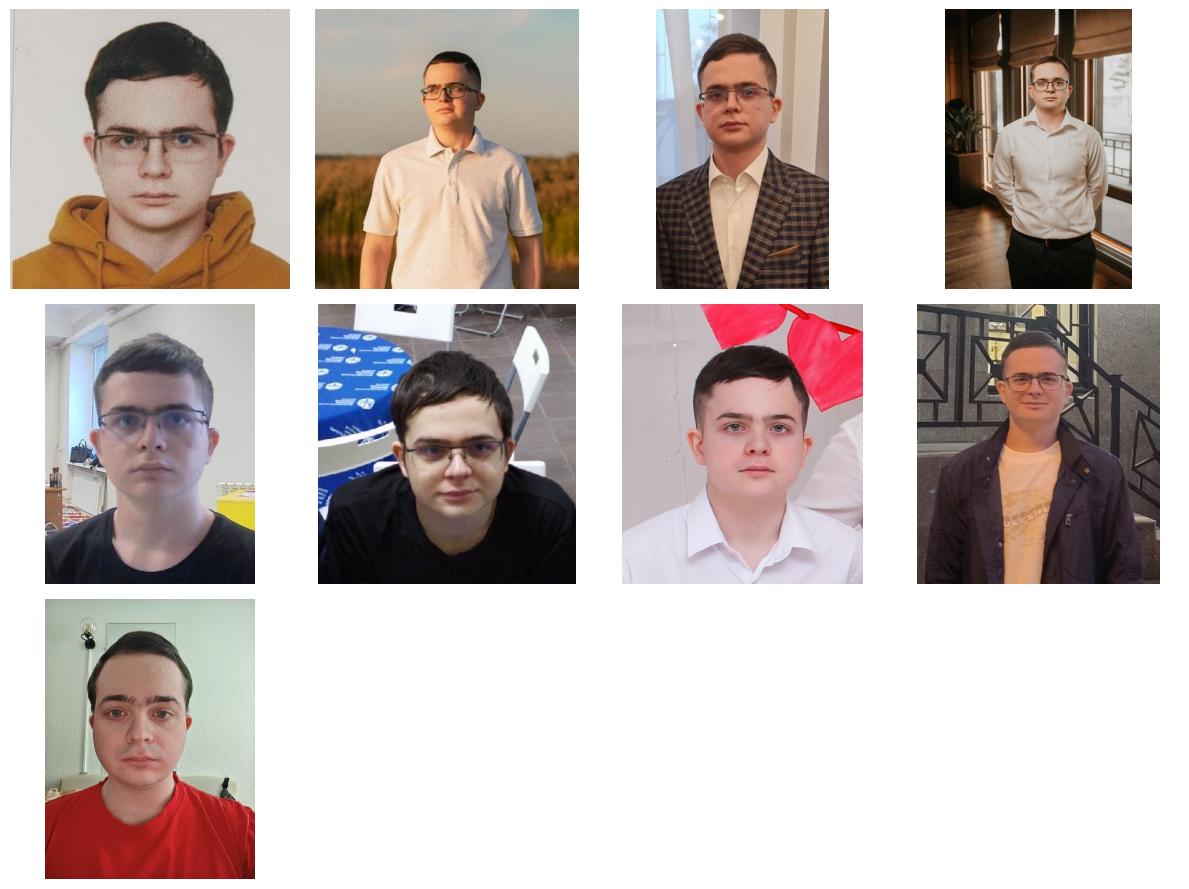

In [2]:
me_photos = sorted(p for p in ME_DIR.iterdir() if p.suffix.lower() in IMG_EXT) if ME_DIR.exists() else []
print(f"фото: {len(me_photos)}")
if len(me_photos) < 5:
    print("мало фото")
else:
    n = min(12, len(me_photos))
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, p in enumerate(me_photos[:n]):
        axes[i].imshow(Image.open(p).convert("RGB"))
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    display(fig)
    plt.close(fig)

## Обучение LoRA

Нужен GPU (на 2060 6 GB хватает: SD 1.5, rank 4, UNet в float32).  

In [ ]:
# Обучение LoRA (только UNet)

RUN_TRAIN = True  # False — пропустить, если веса уже есть

if len(me_photos) < 5:
    print(f"мало фото в dataset/me/: {len(me_photos)} — нужно минимум 5 (лучше 10–20)")
elif LORA_PATH.exists() and not RUN_TRAIN:
    print("обучение пропущено, веса уже есть:", LORA_PATH)
elif RUN_TRAIN:
    import gc
    import torch.nn.functional as F
    from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
    from diffusers.utils import convert_state_dict_to_diffusers
    from peft import LoraConfig
    from peft.utils import get_peft_model_state_dict
    from PIL import ImageOps
    from torch.utils.data import Dataset
    from torchvision import transforms
    from tqdm.auto import tqdm
    from transformers import CLIPTextModel, CLIPTokenizer

    class MeDataset(Dataset):
        def __init__(self, paths, size=512):
            self.paths = paths
            self.tf = transforms.Compose([
                transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.CenterCrop(size),
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5]),
            ])

        def __len__(self):
            return len(self.paths)

        def __getitem__(self, idx):
            img = ImageOps.exif_transpose(Image.open(self.paths[idx])).convert("RGB")
            return {"pixel_values": self.tf(img)}

    # LoRA в float32 — в fp16 у меня веса уходили в NaN
    dtype_vae = torch.float16 if DEVICE == "cuda" else torch.float32
    instance_prompt = f"a photo of {INSTANCE_TOKEN}"
    print("промпт:", instance_prompt, "| фото:", len(me_photos), "| шагов:", TRAIN_STEPS)

    tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder")
    vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae")
    unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet")
    noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

    vae.requires_grad_(False)
    text_encoder.requires_grad_(False)
    vae.to(DEVICE, dtype=dtype_vae)
    text_encoder.to(DEVICE, dtype=dtype_vae)

    unet.add_adapter(LoraConfig(
        r=LORA_RANK, lora_alpha=LORA_RANK, init_lora_weights="gaussian",
        target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    ))
    unet.enable_gradient_checkpointing()
    unet.to(DEVICE, dtype=torch.float32)
    for p in unet.parameters():
        if p.requires_grad:
            p.data = p.data.float()

    loader = torch.utils.data.DataLoader(
        MeDataset(me_photos), batch_size=1, shuffle=True
    )
    with torch.no_grad():
        ids = tokenizer(
            instance_prompt, truncation=True, padding="max_length",
            max_length=tokenizer.model_max_length, return_tensors="pt",
        ).input_ids.to(DEVICE)
        text_embeds = text_encoder(ids)[0]

    trainable = [p for p in unet.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=5e-5, betas=(0.9, 0.999), weight_decay=1e-2)
    grad_accum = 4
    max_grad_norm = 1.0
    data_iter = iter(loader)
    unet.train()

    for step in tqdm(range(TRAIN_STEPS), desc="LoRA"):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)

        pixel_values = batch["pixel_values"].to(DEVICE, dtype=dtype_vae)
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample().float()
            latents = latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=DEVICE,
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
        pred = unet(noisy_latents, timesteps, text_embeds.float()).sample
        loss = F.mse_loss(pred, noise)
        if torch.isnan(loss) or torch.isinf(loss):
            raise RuntimeError(f"loss NaN на шаге {step} — остановка, уменьши lr или TRAIN_STEPS")

        (loss / grad_accum).backward()
        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(trainable, max_grad_norm)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    for p in trainable:
        if torch.isnan(p).any() or torch.isinf(p).any():
            raise RuntimeError("веса LoRA содержат NaN — не сохраняю, переобучи")

    from diffusers import StableDiffusionPipeline

    lora_state = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    StableDiffusionPipeline.save_lora_weights(
        LORA_DIR, unet_lora_layers=lora_state, safe_serialization=True
    )
    print("сохранено:", LORA_PATH)

    del unet, vae, text_encoder, optimizer
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
else:
    print("RUN_TRAIN=False и весов нет — положи адаптер в", LORA_DIR)

W0525 16:14:17.470000 52208 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


промпт: a photo of furore die down | фото: 9 | шагов: 800


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

C:\Users\kanop\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


LoRA:   0%|          | 0/800 [00:00<?, ?it/s]

сохранено: C:\Users\kanop\OneDrive\Рабочий стол\cv\hw5\submit\workspace\lora\pytorch_lora_weights.safetensors


## Загрузка пайплайна

Text2img + LoRA. **Без negative prompt** (по условию).

In [4]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    safety_checker=None,
)
pipe = pipe.to(DEVICE)

def lora_ok(path):
    from safetensors import safe_open
    with safe_open(str(path), framework="pt") as f:
        for k in f.keys():
            t = f.get_tensor(k)
            if torch.isnan(t).any() or torch.isinf(t).any():
                return False
    return True


if LORA_PATH.exists() and lora_ok(LORA_PATH):
    pipe.load_lora_weights(
        str(LORA_DIR),
        weight_name="pytorch_lora_weights.safetensors",
        prefix=None,
    )
    print("LoRA загружена")
elif LORA_PATH.exists():
    print("веса LoRA битые (NaN) — удали файл и переобучи")
else:
    print("LoRA нет — генерация без своего лица")


def generate(prompt, out_path, seed=SEED):
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    img = pipe(
        prompt=prompt,
        negative_prompt=None,
        num_inference_steps=GEN_STEPS,
        guidance_scale=GUIDANCE,
        generator=g,
    ).images[0]
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_path)
    return img


def show_images(files, title=None, ncols=3):
    files = [Path(f) for f in files if Path(f).exists()]
    if not files:
        print("нет картинок для показа")
        return
    n = len(files)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, fp in enumerate(files):
        axes[i].imshow(Image.open(fp).convert("RGB"))
        axes[i].set_title(fp.name, fontsize=9)
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

LoRA загружена


## 5 стилей

Пять портретов с токеном.

  0%|          | 0/50 [00:00<?, ?it/s]

style_1.png ok


  0%|          | 0/50 [00:00<?, ?it/s]

style_2.png ok


  0%|          | 0/50 [00:00<?, ?it/s]

style_3.png ok


  0%|          | 0/50 [00:00<?, ?it/s]

style_4.png ok


  0%|          | 0/50 [00:00<?, ?it/s]

style_5.png ok


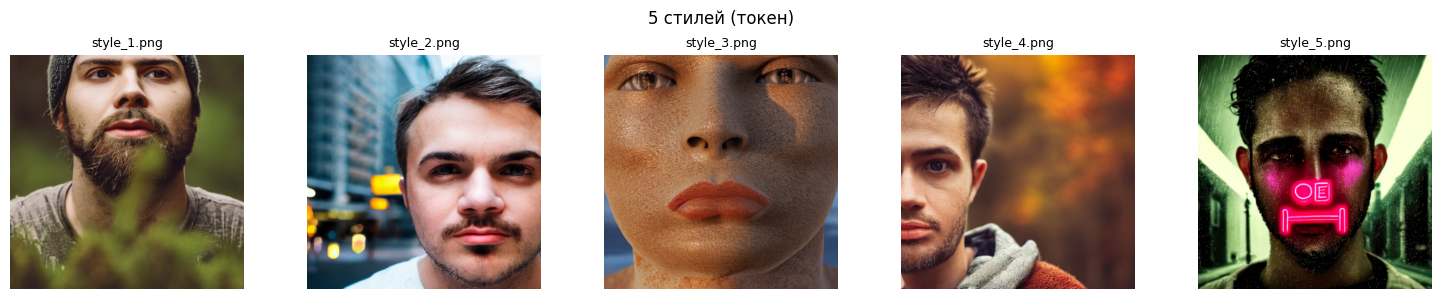

In [29]:
style_prompts = [
    # 1. Лес
    f"a headshot portrait photograph of {INSTANCE_TOKEN} in a forest, front view (face:1.5) in center, looking directly at camera, sharp focus on face, natural sunlight, tall pine trees blurred background, highly detailed, photorealistic, high quality, realism, 8k",

    # 2. Город, улица
    f"a headshot portrait photograph of {INSTANCE_TOKEN} in a city, face in sharp focus, looking at viewer, busy street background blurred, modern architecture, realistic lighting, high quality, ultra realistic",

    # 3. Пляж, золотой час
    f"a medium shot portrait photograph of {INSTANCE_TOKEN} at a beach, front view, detailed face, golden hour, soft waves, warm sunlight, fine sand, highly realistic, high quality, realism, cinematic, 8k",

    # 4. Лес, крупный план
    f"close-up portrait photograph of {INSTANCE_TOKEN} in a forest, autumn colors, bokeh background, sharp details on face, looking at camera, photorealistic, masterpiece, high quality, realism",

    # 5. Город ночью
    f"a portrait photograph of {INSTANCE_TOKEN} in a city at night, face illuminated by soft neon key light, front view, looking directly at camera, wet pavement, cinematic mood, highly detailed, photorealistic, high quality, realism, 8k"    
	
	# f"photo of {INSTANCE_TOKEN} in a forest, face visible, high quality, realism",
	# f"photo of {INSTANCE_TOKEN} in a city, face visible, high quality, realism",
	# f"photo of {INSTANCE_TOKEN} in a beach, face visible, high quality, realism",
	# f"photo of {INSTANCE_TOKEN} in a trashcan, face visible, high quality, realism",
	# f"photo of {INSTANCE_TOKEN} in a jail, face visible, high quality, realism",
    
]

style_dir = OUT_DIR / "styles"
for i, pr in enumerate(style_prompts):
    p = style_dir / f"style_{i+1}.png"
    generate(pr, p, seed=SEED + i)
    print(p.name, "ok")

show_images(
    [style_dir / f"style_{i+1}.png" for i in range(len(style_prompts))],
    title="5 стилей (токен)",
    ncols=5,
)

## Токен + forest / city / beach

  0%|          | 0/50 [00:00<?, ?it/s]

forest ok


  0%|          | 0/50 [00:00<?, ?it/s]

city ok


  0%|          | 0/50 [00:00<?, ?it/s]

beach ok


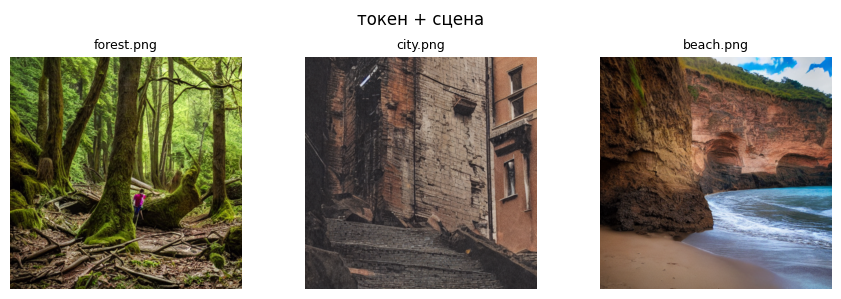

In [31]:
scenes = ["forest", "city", "beach"]
token_dir = OUT_DIR / "token"
for i, sc in enumerate(scenes):
    pr = f"photo of {INSTANCE_TOKEN} in a {sc}, face visible, high quality, realism"
    generate(pr, token_dir / f"{sc}.png", seed=SEED + 100 + i)
    print(sc, "ok")

show_images([token_dir / f"{sc}.png" for sc in scenes], title="токен + сцена", ncols=3)

## Пол (man / woman) + forest / city / beach

Без токена — мужчина и женщина, чтобы проверить, что модель не «сломалась».

  0%|          | 0/50 [00:00<?, ?it/s]

man forest ok


  0%|          | 0/50 [00:00<?, ?it/s]

man city ok


  0%|          | 0/50 [00:00<?, ?it/s]

...

woman forest ok


  0%|          | 0/50 [00:00<?, ?it/s]

woman city ok


  0%|          | 0/50 [00:00<?, ?it/s]

woman beach ok


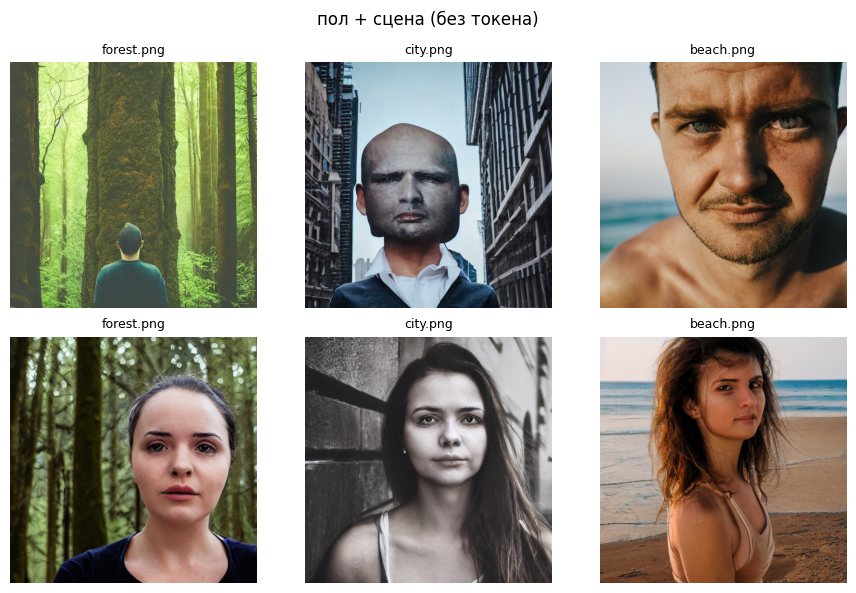

In [22]:
gender_dir = OUT_DIR / "gender"
genders = ["man", "woman"]

for gi, g in enumerate(genders):
    for i, sc in enumerate(scenes):
        pr = f"photo of a {g} in a {sc}, huge face visible, high quality, realism, 8k"
        out = gender_dir / g / f"{sc}.png"
        generate(pr, out, seed=SEED + 201 + gi * 10 + i)
        print(g, sc, "ok")

gender_show = []
for g in genders:
    for sc in scenes:
        gender_show.append(gender_dir / g / f"{sc}.png")
show_images(gender_show, title="пол + сцена (без токена)", ncols=3)

## Метрики (не FID / IS)

1. **CLIP** — cosine эмбеддинга текста и картинки (чем выше, тем ближе к промпту)  
2. **face_sim** — cosine эмбеддинга картинки и среднего по фото из `me/`  
3. **LPIPS** — перцептивное расстояние до референса (меньше = ближе)

In [26]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


@torch.no_grad()
def clip_text_emb(prompt):
    inputs = clip_proc(text=[prompt], return_tensors="pt", padding=True).to(DEVICE)
    out = clip_model.text_model(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)
    idx = inputs.attention_mask.sum(dim=-1) - 1
    pooled = out.last_hidden_state[torch.arange(out.last_hidden_state.shape[0]), idx]
    emb = clip_model.text_projection(pooled)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb[0].cpu().numpy()


@torch.no_grad()
def clip_text_image_score(prompt, image_path):
    # cosine между эмбеддингами текста и картинки (не softmax — он всегда 1 для одной пары)
    return float(np.dot(clip_text_emb(prompt), clip_image_emb(image_path)))


@torch.no_grad()
def clip_image_emb(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = clip_proc(images=img, return_tensors="pt").to(DEVICE)
    vision_out = clip_model.vision_model(pixel_values=inputs["pixel_values"])
    emb = clip_model.visual_projection(vision_out.pooler_output)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb[0].cpu().numpy()


def cosine(a, b):
    a, b = np.asarray(a).flatten(), np.asarray(b).flatten()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


ref_embs = [clip_image_emb(p) for p in me_photos[:5]] if me_photos else []
ref_mean = np.mean(ref_embs, axis=0) if ref_embs else None
prompt_by_file = {f"style_{i+1}.png": style_prompts[i] for i in range(len(style_prompts))}

lpips_fn = None
lpips_t = None
try:
    import lpips
    import torchvision.transforms as T
    lpips_fn = lpips.LPIPS(net="alex").to(DEVICE)
    lpips_t = T.Compose([T.Resize((256, 256)), T.ToTensor()])
except ImportError:
    pass

metrics_rows = []
for gf in sorted(style_dir.glob("*.png")):
    row = {"file": gf.name}
    row["clip"] = clip_text_image_score(prompt_by_file.get(gf.name, ""), gf)
    if ref_mean is not None:
        row["face_sim"] = cosine(clip_image_emb(gf), ref_mean)
    if lpips_fn is not None and me_photos:
        a = lpips_t(Image.open(gf).convert("RGB")).unsqueeze(0).to(DEVICE) * 2 - 1
        b = lpips_t(Image.open(me_photos[0]).convert("RGB")).unsqueeze(0).to(DEVICE) * 2 - 1
        row["lpips"] = float(lpips_fn(a, b).cpu())
    metrics_rows.append(row)

print(metrics_rows)
(METRICS_DIR / "generated.json").write_text(
    json.dumps(metrics_rows, indent=2, ensure_ascii=False), encoding="utf-8"
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: C:\Users\kanop\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lpips\weights\v0.1\alex.pth
[{'file': 'style_1.png', 'clip': 0.3289288878440857, 'face_sim': 0.6959026455879211, 'lpips': 0.6945630311965942}, {'file': 'style_2.png', 'clip': 0.32012683153152466, 'face_sim': 0.7488023638725281, 'lpips': 0.694936990737915}, {'file': 'style_3.png', 'clip': 0.2890596091747284, 'face_sim': 0.5951396822929382, 'lpips': 0.7861842513084412}, {'file': 'style_4.png', 'clip': 0.32207125425338745, 'face_sim': 0.7350374460220337, 'lpips': 0.825761079788208}, {'file': 'style_5.png', 'clip': 0.27241039276123047, 'face_sim': 0.47006598114967346, 'lpips': 0.7009349465370178}]


684

## Вывод

Обучил LoRA на **Stable Diffusion 1.5** по **9** фото из `dataset/me/`. Токен **`furore die down`**, при обучении промпт `a photo of furore die down`. LoRA на UNet: **800** шагов, rank **4**, float32 (в fp16 были NaN в весах). Генерация: **50** шагов, guidance **7.5**, без negative prompt.

**Пять стилей** (`workspace/outputs/styles/`, все с токеном):
| файл | сцена | CLIP | face_sim | LPIPS |
|------|--------|------|----------|-------|
| style_1 | лес, анфас | 0.33 | 0.70 | 0.69 |
| style_2 | город, портрет | 0.32 | 0.75 | 0.69 |
| style_3 | пляж | 0.29 | 0.60 | 0.79 |
| style_4 | лес, крупный план | 0.32 | 0.74 | 0.83 |
| style_5 | город ночью | 0.27 | 0.47 | 0.70 |

Лучше всего узнаётся лицо на **style_2** и **style_4**; на **style_5** сходство слабое — для сдачи всё равно оставил все пять, потому что по условию нужны 5 разных вариантов.

**Токен + сцены** — `outputs/token/` (forest, city, beach): сцены читаются, лицо не везде похоже на меня.

**Без токена** — `outputs/gender/man/` и `woman/` (те же три сцены): генерируются разные люди, модель для обычных промптов с man/woman не сломалась.

**Метрики** (см. `workspace/metrics/generated.json`):
1. **CLIP** — cosine эмбеддинга промпта и картинки (обычно ~0.25–0.35, выше = лучше match).
2. **face_sim** — cosine эмбеддинга картинки и среднего по 5 фото из `me/`.
3. **LPIPS** — расстояние до одного референсного фото; меньше = ближе (у меня примерно 0.69–0.83).

FID и IS не считал — по заданию нужны другие метрики.

**Ограничения:** text2img, локально, без API, img2img и negative prompt.